# Cube-Quadruple Horizon Subgoal Proposer

Train a horizon-conditioned subgoal proposer for `cube-quadruple-play-v0` using the shared implementation in `agents/goal_proposer.py`. This notebook only handles cube-specific configuration, training, and visualization.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import trange

from agents.goal_proposer import (
    GCFlowGoalProposerAgent,
    GoalProposerCGCDataset,
    make_goal_proposer_config,
)
from utils.flax_utils import save_agent
from wrappers.datafuncs_utils import make_env_and_datasets


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [8]:
base_config = dict(
    env_name='cube-quadruple-play-v0',
    dataset_path='../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
    observations_key='oracle_reps',
    goal_key='actor_goals',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    flow_steps=10,
    discount=0.995,
    backup_horizon=25,
    seed=0,
)

config = make_goal_proposer_config(
    'cube_quadruple_horizon_subgoal_proposer',
    observation_conditioned=True,
    horizon_conditioned=True,
    base_config=base_config,
)
config.update(
    batch_size=256,
    num_train_steps=50_000,
    log_interval=500,
    min_horizon_steps=1,
    max_horizon_steps=250,
    subgoal_steps=250,
    horizon_scale=250.0,
    output_dir='checkpoints/cube_quadruple_horizon_subgoal_proposer',
)
config

{'env_name': 'cube-quadruple-play-v0',
 'dataset_path': '../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'flow_steps': 10,
 'discount': 0.995,
 'backup_horizon': 25,
 'seed': 0,
 'output_dir': 'checkpoints/cube_quadruple_horizon_subgoal_proposer',
 'num_train_steps': 50000,
 'batch_size': 256,
 'log_interval': 500,
 'actions_key': 'low_actor_goals',
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'goal_conditioned': False,
 'observation_conditioned': True,
 'horizon_conditioned': True,
 'horizon_key': 'horizons',
 'min_horizon_steps': 1,
 'max_horizon_steps': 250,
 'subgoal_steps': 250,
 'horizon_scale': 250.0}

`GoalProposerCGCDataset` handles the horizon-conditioned relabeling: it samples a transition index `i`, draws a horizon `n`, and trains against the oracle representation at `min(i + n, episode_end)`. For this environment, the oracle representation is the concatenated xyz positions of the 4 cubes.

In [9]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=base_config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = GoalProposerCGCDataset(base_train_dataset, config=config)

example_batch = train_dataset.sample(config['batch_size'])
num_cubes = int(env.unwrapped._num_cubes)

print('env:', env.spec.id)
print('num_cubes:', num_cubes)
print('dataset keys:', sorted(base_train_dataset.keys()))
print('example batch keys:', sorted(example_batch.keys()))
print('observations:', example_batch[config['observations_key']].shape)
print('target subgoals:', example_batch[config['actions_key']].shape)
print('horizons:', example_batch[config['horizon_key']].shape)
print('horizon range:', float(example_batch[config['horizon_key']].min()), float(example_batch[config['horizon_key']].max()))


env: cube-quadruple-v0
num_cubes: 4
dataset keys: ['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
example batch keys: ['actions', 'horizons', 'low_actor_goals', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
observations: (256, 12)
target subgoals: (256, 12)
horizons: (256, 1)
horizon range: 4.0 250.0


In [10]:
agent = GCFlowGoalProposerAgent.create(example_batch, config)
history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

pbar = trange(1, config['num_train_steps'] + 1)
for step in pbar:
    batch = train_dataset.sample(config['batch_size'])
    agent, info = agent.update(batch)

    for key in history:
        history[key].append(float(info[key]))

    if step == 1 or step % config['log_interval'] == 0:
        pbar.set_description(
            f"loss={history['flow_loss'][-1]:.4f} mae={history['velocity_mae'][-1]:.4f}"
        )


loss=0.7439 mae=0.4884: 100%|██████████| 50000/50000 [07:37<00:00, 109.32it/s]


In [ ]:
Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
save_agent(agent, config['output_dir'], step)

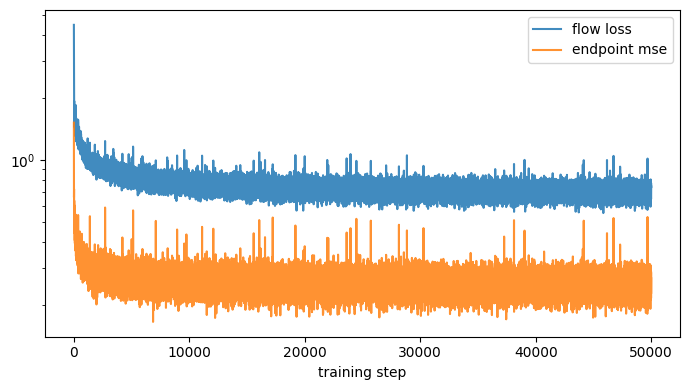

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(history['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.legend()
fig.tight_layout()


The visualization below plots each cube separately in XY space. Gray points are all positions that cube occupies in the dataset, blue points are proposer samples, the red `x` is the current position, and the green `*` is the dataset target for that horizon.

## Subgoal rollouts per task

For each of the 5 tasks we run a greedy subgoal chain in oracle space: at every step the proposer samples `num_samples` subgoals conditioned on the current oracle observation and a fixed horizon, and the chain moves to whichever subgoal is closest (L2) to the task goal. Each cube's XY trajectory is plotted separately.

In [14]:
def subgoal_rollout(agent, start_oracle, goal_oracle, horizon, num_samples, num_steps, rng):
    """Greedy subgoal chain in oracle space.

    At each step, sample `num_samples` subgoals from the proposer and advance
    to whichever is closest (L2) to `goal_oracle`.
    Returns an array of shape (num_steps + 1, obs_dim).
    """
    obs = np.asarray(start_oracle, dtype=np.float32)
    goal = np.asarray(goal_oracle, dtype=np.float32)
    trajectory = [obs.copy()]
    for _ in range(num_steps):
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(agent.sample_actions(
            observations=obs,
            horizons=float(horizon),
            rng=sample_rng,
            num_samples=num_samples,
        ))
        best = subgoals[int(np.argmin(np.linalg.norm(subgoals - goal, axis=-1)))]
        trajectory.append(best.copy())
        obs = best
    return np.stack(trajectory)  # (num_steps + 1, obs_dim)


def plot_subgoal_rollout(trajectory, goal_oracle, all_cube_xyz, num_cubes, title=''):
    """Plot each cube's XY trajectory from a subgoal rollout."""
    traj_xyz = reshape_cube_reps(trajectory, num_cubes)       # (T, num_cubes, 3)
    goal_xyz = np.asarray(goal_oracle, dtype=np.float32).reshape(num_cubes, 3)

    fig, axes = plt.subplots(1, num_cubes, figsize=(4 * num_cubes, 4), squeeze=False)
    axes = axes[0]
    cmap = plt.cm.Blues
    for cube_idx in range(num_cubes):
        ax = axes[cube_idx]
        ax.scatter(
            all_cube_xyz[:, cube_idx, 0], all_cube_xyz[:, cube_idx, 1],
            s=4, c='0.88', linewidths=0,
        )
        T = len(traj_xyz)
        for t in range(T - 1):
            ax.plot(
                traj_xyz[t:t + 2, cube_idx, 0],
                traj_xyz[t:t + 2, cube_idx, 1],
                c=cmap(0.3 + 0.7 * t / max(T - 2, 1)),
                lw=1.5,
            )
        ax.scatter(*traj_xyz[0, cube_idx, :2], marker='x', s=100, c='red', zorder=5, label='start')
        ax.scatter(*traj_xyz[-1, cube_idx, :2], marker='o', s=80, c='orange', zorder=5, label='final')
        ax.scatter(*goal_xyz[cube_idx, :2], marker='*', s=120, c='green', zorder=5, label='goal')
        ax.set_title(f'cube {cube_idx}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    axes[0].legend(loc='best', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig

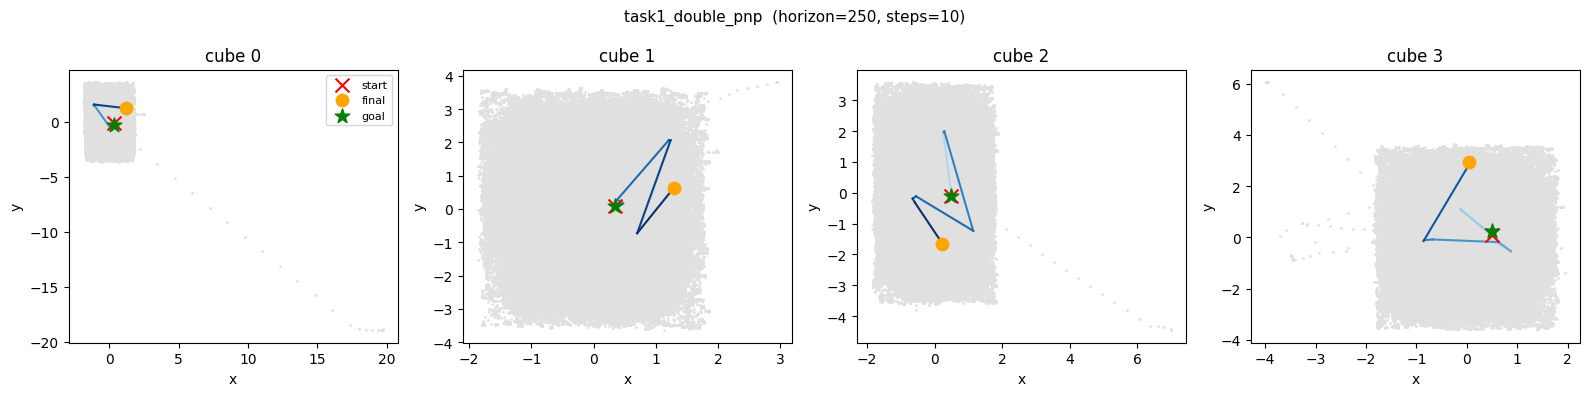

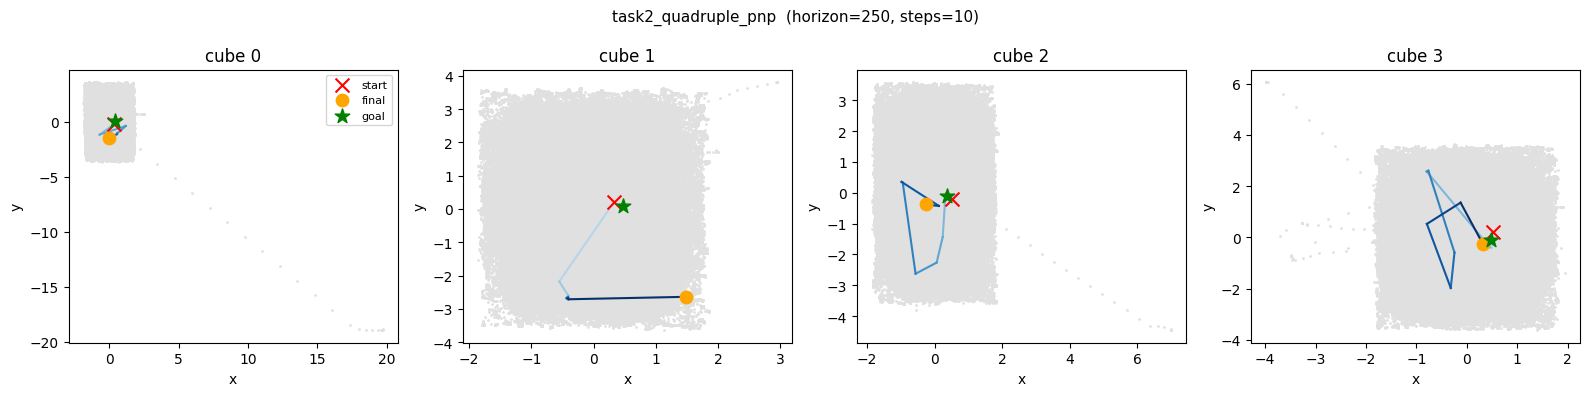

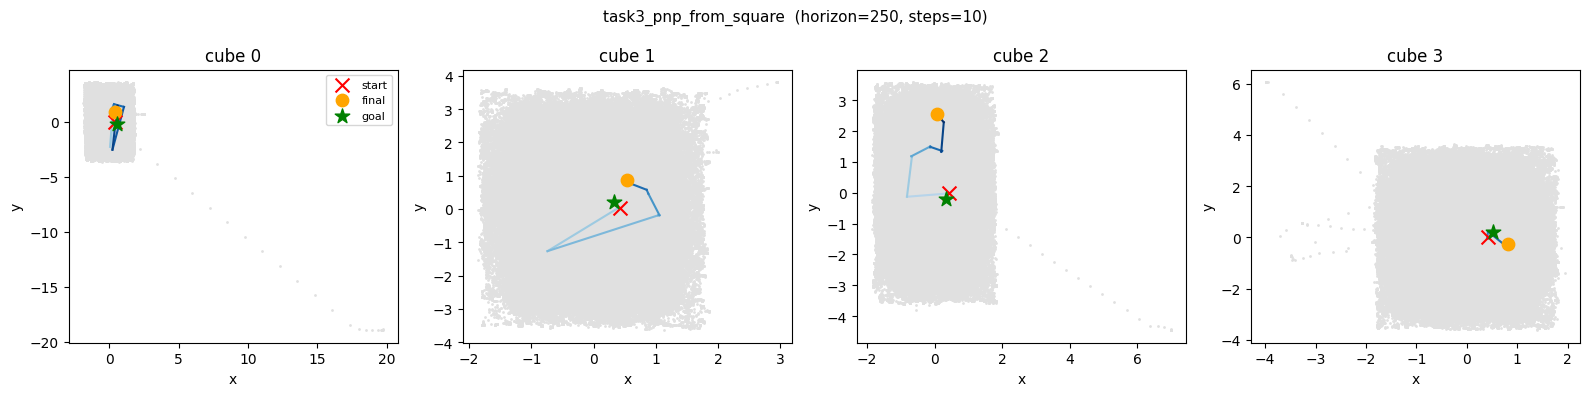

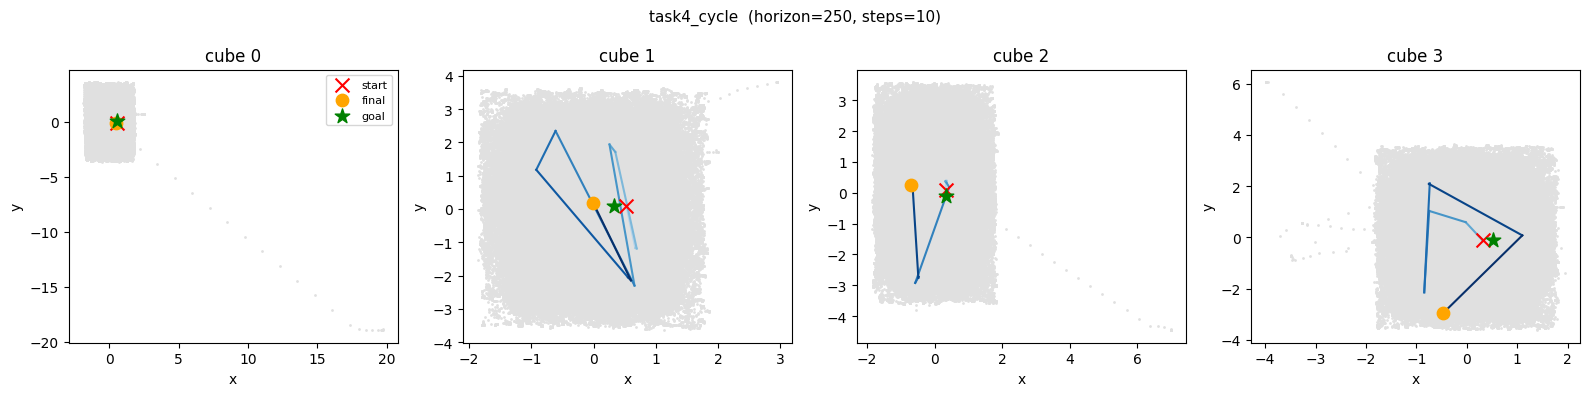

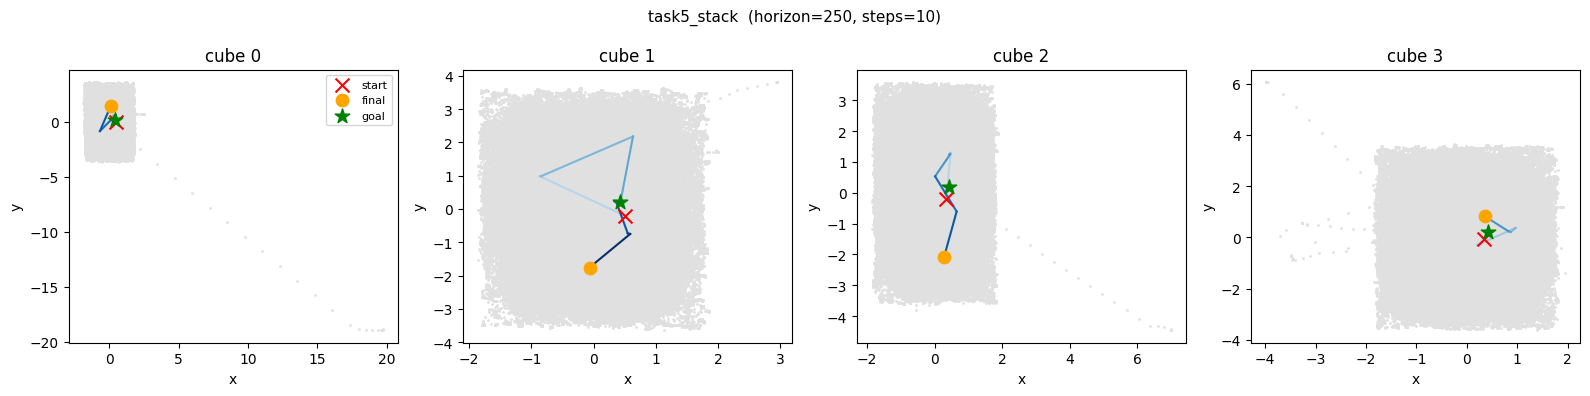

In [15]:
rollout_horizon = config['subgoal_steps']  # horizon for each proposer step
rollout_num_samples = 128                  # subgoals sampled per step
rollout_num_steps = 10                     # chain length
rollout_seed = config['seed']

task_infos = env.unwrapped.task_infos

rng = jax.random.PRNGKey(rollout_seed)
for task_info in task_infos:
    start_oracle = task_info['init_xyzs'].flatten().astype(np.float32)
    goal_oracle = task_info['goal_xyzs'].flatten().astype(np.float32)

    rng, rollout_rng = jax.random.split(rng)
    trajectory = subgoal_rollout(
        agent, start_oracle, goal_oracle,
        horizon=rollout_horizon,
        num_samples=rollout_num_samples,
        num_steps=rollout_num_steps,
        rng=rollout_rng,
    )
    plot_subgoal_rollout(
        trajectory, goal_oracle, all_cube_xyz, num_cubes,
        title=f"{task_info['task_name']}  (horizon={rollout_horizon}, steps={rollout_num_steps})",
    )
    plt.show()

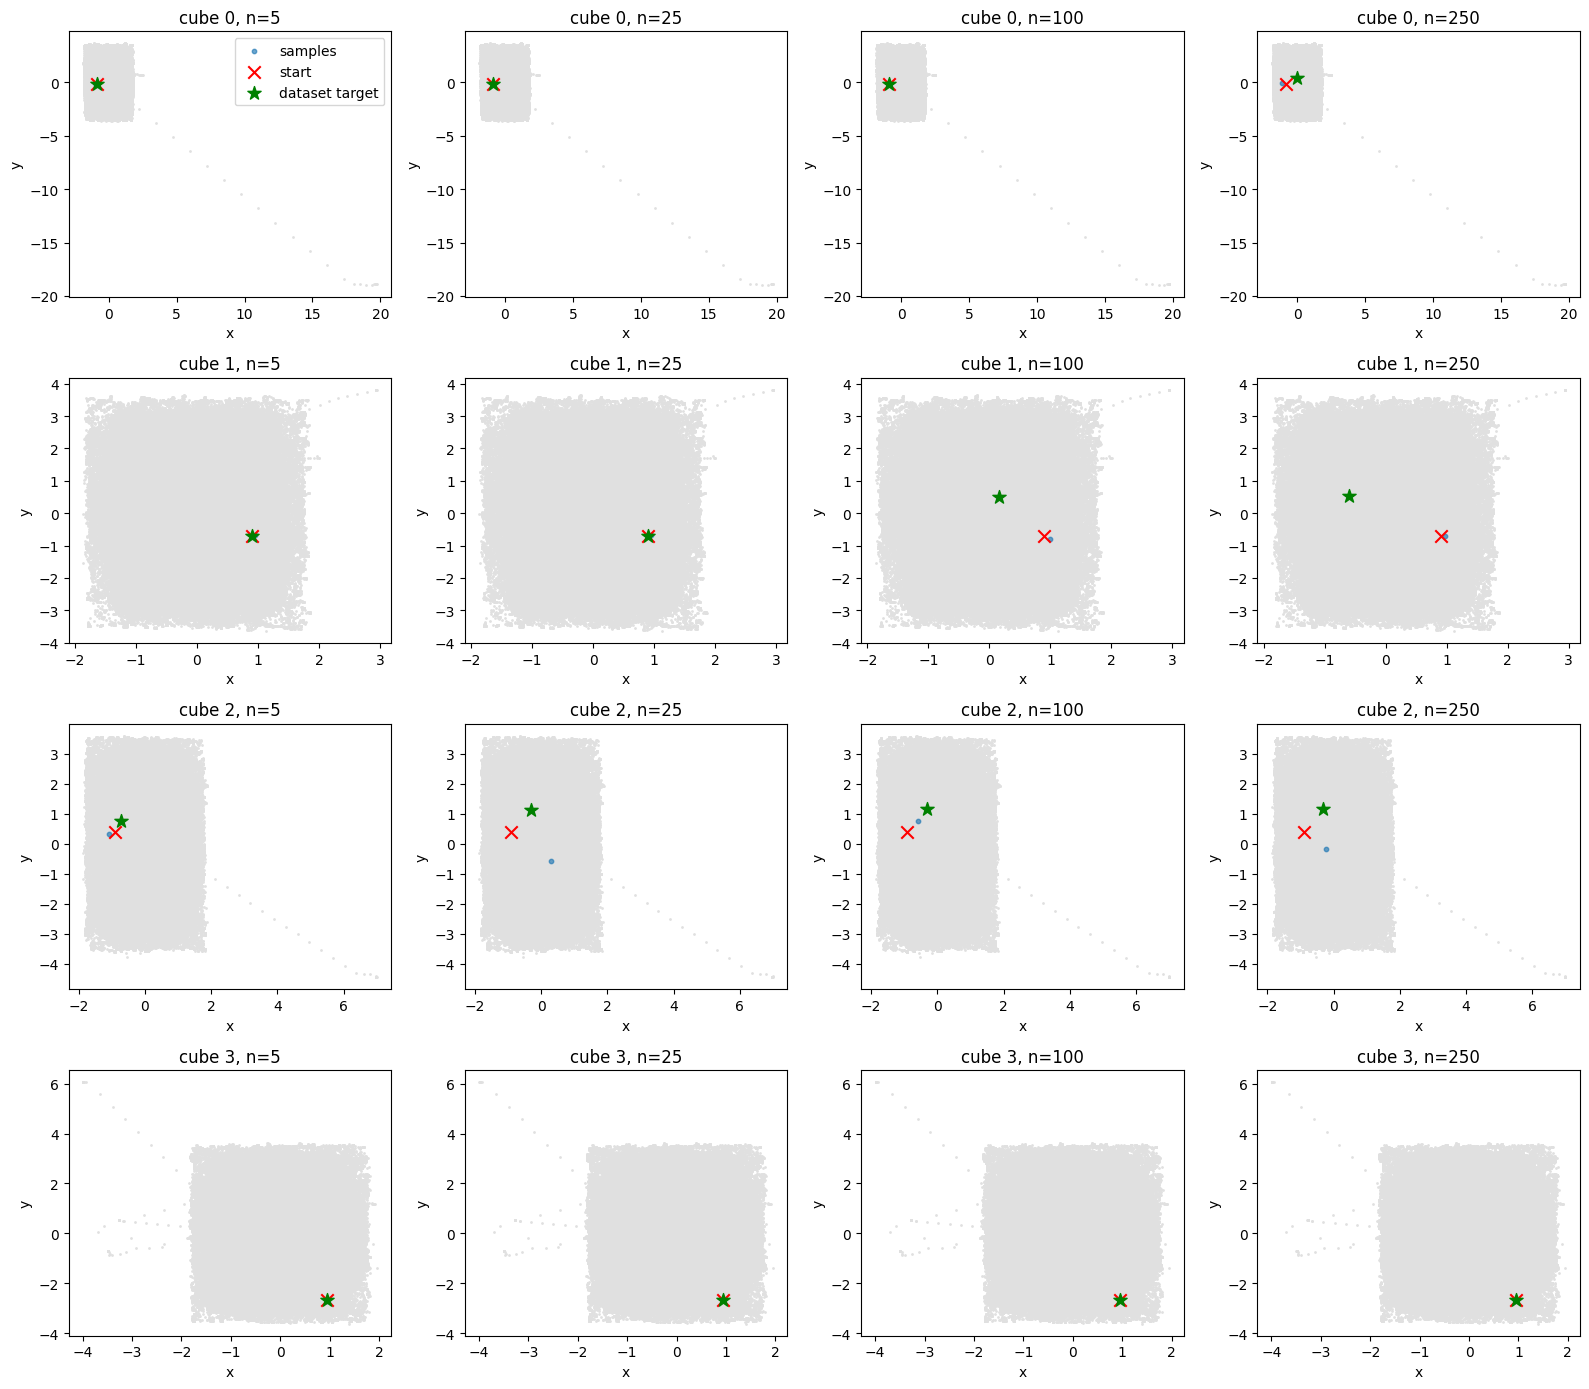

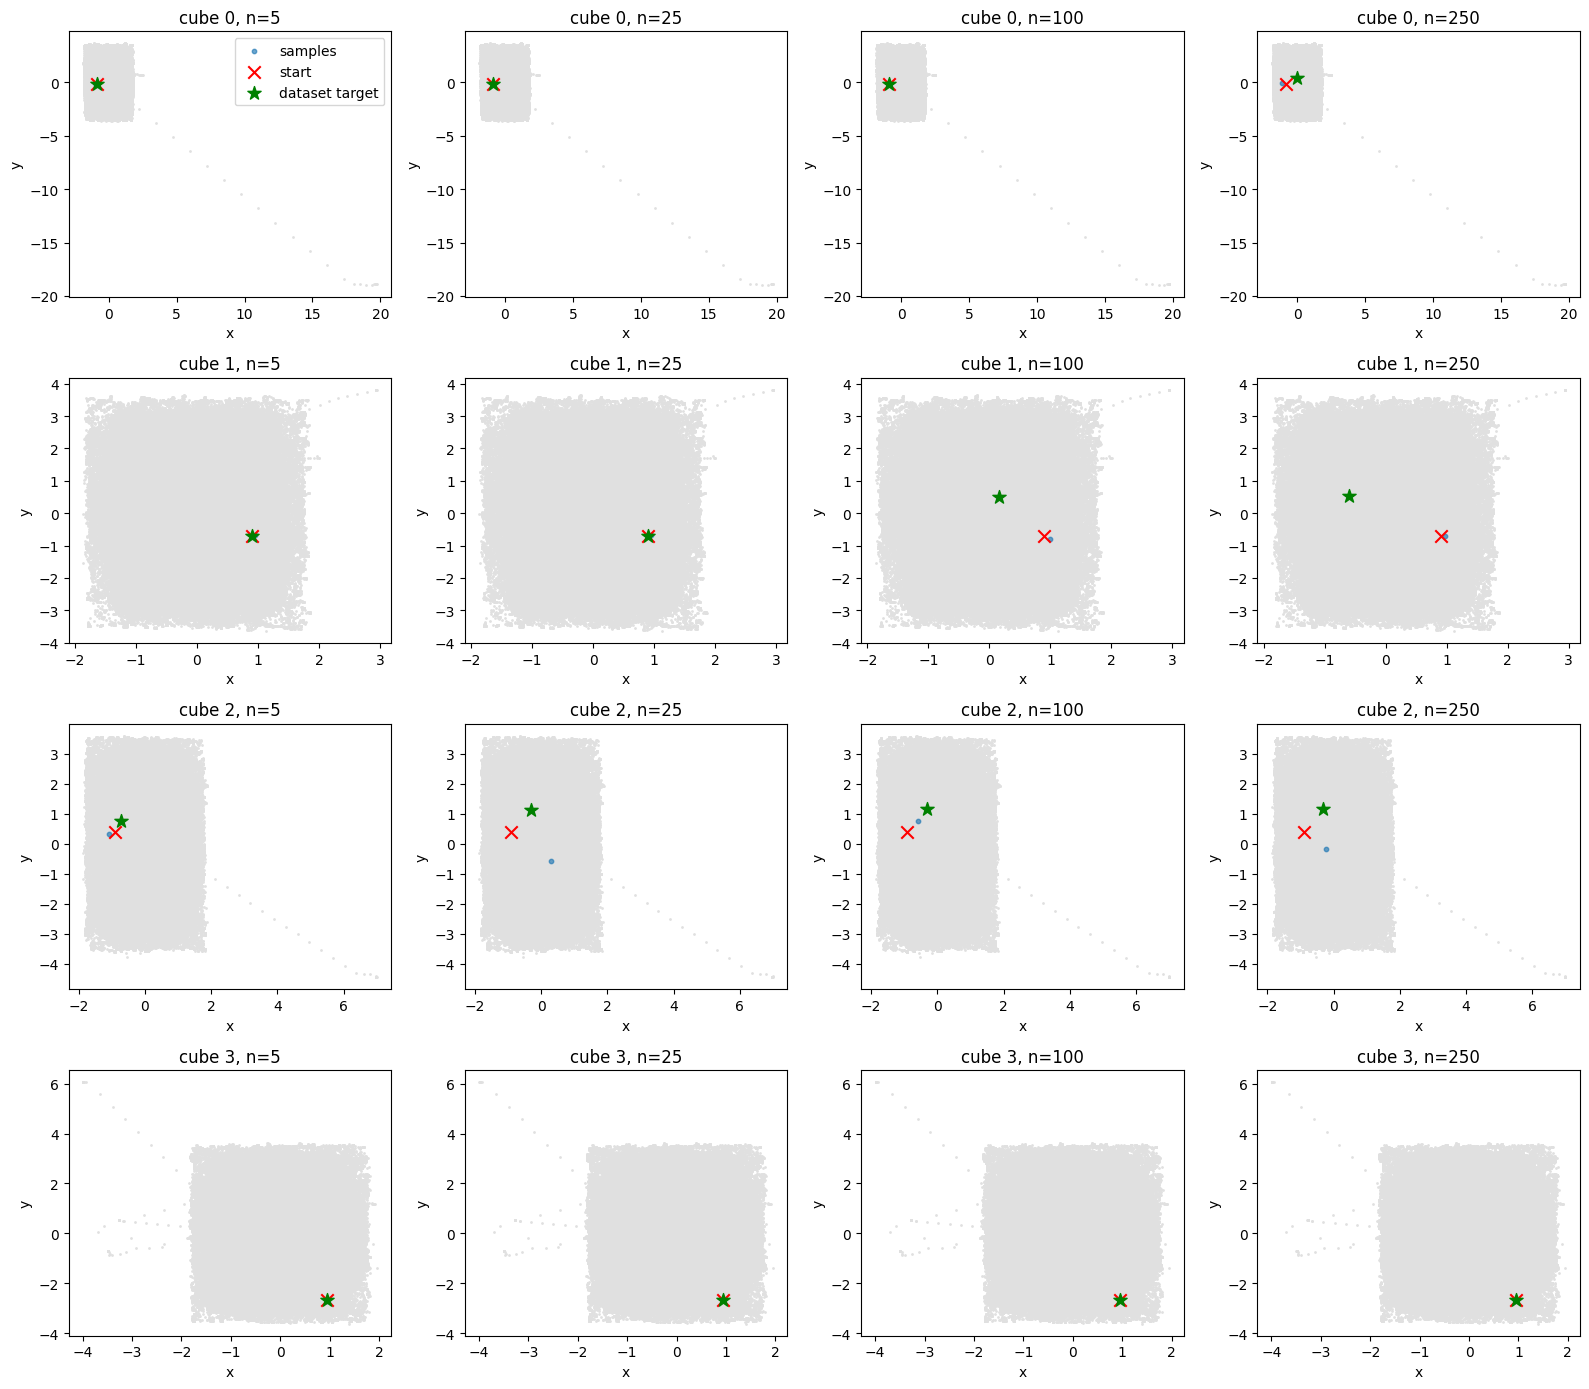

In [16]:
def reshape_cube_reps(reps, num_cubes):
    reps = np.asarray(reps, dtype=np.float32)
    return reps.reshape(reps.shape[0], num_cubes, 3)


all_cube_xyz = reshape_cube_reps(base_train_dataset['oracle_reps'], num_cubes)


def plot_cube_horizon_samples(dataset, agent, idx, horizons=(5, 25, 100, 250), num_samples=128, seed=0):
    idx = int(idx)
    rng = jax.random.PRNGKey(seed)

    observation = np.asarray(dataset.dataset['oracle_reps'][idx], dtype=np.float32)
    final_idx = dataset.terminal_locs[np.searchsorted(dataset.terminal_locs, idx)]
    observation_xyz = observation.reshape(num_cubes, 3)

    fig, axes = plt.subplots(
        num_cubes,
        len(horizons),
        figsize=(4 * len(horizons), 3.5 * num_cubes),
        sharex=False,
        sharey=False,
    )
    if num_cubes == 1:
        axes = np.asarray([axes])
    if len(horizons) == 1:
        axes = axes[:, None]

    for col, horizon in enumerate(horizons):
        target_idx = min(idx + int(horizon), int(final_idx))
        target = np.asarray(dataset.dataset['oracle_reps'][target_idx], dtype=np.float32)
        target_xyz = target.reshape(num_cubes, 3)

        rng, sample_rng = jax.random.split(rng)
        samples = np.asarray(
            agent.sample_actions(
                observations=observation,
                horizons=float(horizon),
                rng=sample_rng,
                num_samples=num_samples,
            )
        )
        samples_xyz = reshape_cube_reps(samples, num_cubes)

        for cube_idx in range(num_cubes):
            ax = axes[cube_idx, col]
            ax.scatter(all_cube_xyz[:, cube_idx, 0], all_cube_xyz[:, cube_idx, 1], s=4, c='0.88', linewidths=0)
            ax.scatter(samples_xyz[:, cube_idx, 0], samples_xyz[:, cube_idx, 1], s=10, alpha=0.65, label='samples')
            ax.scatter(observation_xyz[cube_idx, 0], observation_xyz[cube_idx, 1], marker='x', s=80, c='red', label='start')
            ax.scatter(target_xyz[cube_idx, 0], target_xyz[cube_idx, 1], marker='*', s=100, c='green', label='dataset target')
            ax.set_title(f'cube {cube_idx}, n={int(horizon)}')
            ax.set_xlabel('x')
            ax.set_ylabel('y')

    axes[0, 0].legend(loc='best')
    fig.tight_layout()
    return fig


valid_idx = int(train_dataset.dataset.get_random_idxs(1)[0])
plot_cube_horizon_samples(train_dataset, agent, valid_idx, seed=config['seed'])


In [17]:
Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
save_agent(agent, config['output_dir'], config['num_train_steps'])


Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_50000.pkl


## Continue training: observation+horizon-conditioned proposer (+1 M steps)

Restore from the 50 k checkpoint and run 1 M additional gradient steps, saving every 100 k steps.

In [18]:
from utils.flax_utils import restore_agent
from agents.goal_proposer import latest_checkpoint_step

EXTRA_STEPS = 1_000_000
SAVE_INTERVAL = 100_000

ckpt_step = latest_checkpoint_step(config['output_dir'])
agent = GCFlowGoalProposerAgent.create(example_batch, config)
agent = restore_agent(agent, config['output_dir'], ckpt_step)
print(f'Restored from step {ckpt_step}; training {EXTRA_STEPS} more steps')

history_continued = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])
pbar = trange(1, EXTRA_STEPS + 1)
for step in pbar:
    batch = train_dataset.sample(config['batch_size'])
    agent, info = agent.update(batch)
    for key in history_continued:
        history_continued[key].append(float(info[key]))
    if step % 5_000 == 0:
        pbar.set_description(
            f"loss={history_continued['flow_loss'][-1]:.4f} mae={history_continued['velocity_mae'][-1]:.4f}"
        )
    if step % SAVE_INTERVAL == 0:
        global_step = ckpt_step + step
        save_agent(agent, config['output_dir'], global_step)
        print(f'  checkpoint at global step {global_step}')

Restored from checkpoints/cube_quadruple_horizon_subgoal_proposer/params_50000.pkl
Restored from step 50000; training 1000000 more steps


loss=0.6977 mae=0.4628:  10%|█         | 100018/1000000 [14:37<2:06:48, 118.29it/s]

Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_150000.pkl
  checkpoint at global step 150000


loss=0.6864 mae=0.4613:  20%|██        | 200020/1000000 [30:15<2:09:45, 102.76it/s]

Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_250000.pkl
  checkpoint at global step 250000


...

Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_850000.pkl
  checkpoint at global step 850000


loss=0.7400 mae=0.4645:  90%|█████████ | 900019/1000000 [2:20:26<16:00, 104.10it/s]

Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_950000.pkl
  checkpoint at global step 950000


loss=0.6590 mae=0.4476: 100%|██████████| 1000000/1000000 [2:36:11<00:00, 106.70it/s]

Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_1050000.pkl
  checkpoint at global step 1050000


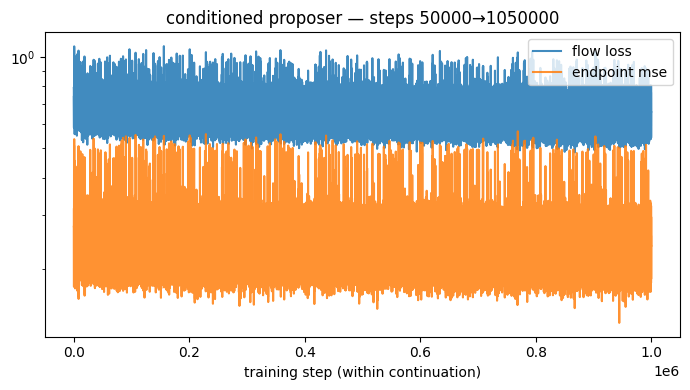

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_continued['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(history_continued['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step (within continuation)')
ax.set_title(f'conditioned proposer — steps {ckpt_step}→{ckpt_step + EXTRA_STEPS}')
ax.legend()
fig.tight_layout()

## Unconditioned (horizon-only) proposer (2 M steps)

Train a proposer with `observation_conditioned=False` — it receives no current-state information, only the encoded horizon length. The network learns a horizon-conditioned marginal distribution over reachable states, ignoring where the agent currently is. Saves every 200 k steps.

In [20]:
uncond_config = make_goal_proposer_config(
    'cube_quadruple_unconditioned_subgoal_proposer',
    observation_conditioned=False,
    horizon_conditioned=True,
    base_config=base_config,
)
uncond_config.update(
    batch_size=256,
    num_train_steps=2_000_000,
    log_interval=5_000,
    min_horizon_steps=1,
    max_horizon_steps=250,
    subgoal_steps=250,
    horizon_scale=250.0,
    output_dir='checkpoints/cube_quadruple_unconditioned_subgoal_proposer',
)
uncond_config

{'env_name': 'cube-quadruple-play-v0',
 'dataset_path': '../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'flow_steps': 10,
 'discount': 0.995,
 'backup_horizon': 25,
 'seed': 0,
 'output_dir': 'checkpoints/cube_quadruple_unconditioned_subgoal_proposer',
 'num_train_steps': 2000000,
 'batch_size': 256,
 'log_interval': 5000,
 'actions_key': 'low_actor_goals',
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'goal_conditioned': False,
 'observation_conditioned': False,
 'horizon_conditioned': True,
 'horizon_key': 'horizons',
 'min_horizon_steps': 1,
 'max_horizon_steps': 250,
 'subgoal_steps': 250,
 'horizon_scale': 250.0}

In [21]:
UNCOND_SAVE_INTERVAL = 200_000

from pathlib import Path
Path(uncond_config['output_dir']).mkdir(parents=True, exist_ok=True)

uncond_agent = GCFlowGoalProposerAgent.create(example_batch, uncond_config)
history_uncond = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

pbar = trange(1, uncond_config['num_train_steps'] + 1)
for step in pbar:
    batch = train_dataset.sample(uncond_config['batch_size'])
    uncond_agent, info = uncond_agent.update(batch)
    for key in history_uncond:
        history_uncond[key].append(float(info[key]))
    if step % 5_000 == 0:
        pbar.set_description(
            f"loss={history_uncond['flow_loss'][-1]:.4f} mae={history_uncond['velocity_mae'][-1]:.4f}"
        )
    if step % UNCOND_SAVE_INTERVAL == 0:
        save_agent(uncond_agent, uncond_config['output_dir'], step)
        print(f'  checkpoint at step {step}')

save_agent(uncond_agent, uncond_config['output_dir'], uncond_config['num_train_steps'])
print(f'Saved final unconditioned proposer to {uncond_config["output_dir"]}')

loss=1.4059 mae=0.8496:  10%|█         | 200018/2000000 [31:09<4:43:00, 106.00it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_200000.pkl
  checkpoint at step 200000


loss=1.4414 mae=0.8662:  20%|██        | 400013/2000000 [1:02:16<4:11:10, 106.16it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_400000.pkl
  checkpoint at step 400000


loss=1.3876 mae=0.8368:  30%|███       | 600017/2000000 [1:33:26<3:43:33, 104.37it/s]

...

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_1600000.pkl
  checkpoint at step 1600000


loss=1.3567 mae=0.8192:  90%|█████████ | 1800018/2000000 [4:40:24<31:14, 106.66it/s]  

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_1800000.pkl
  checkpoint at step 1800000


loss=1.3482 mae=0.8363: 100%|██████████| 2000000/2000000 [5:11:34<00:00, 106.98it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_2000000.pkl
  checkpoint at step 2000000
Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_2000000.pkl
Saved final unconditioned proposer to checkpoints/cube_quadruple_unconditioned_subgoal_proposer


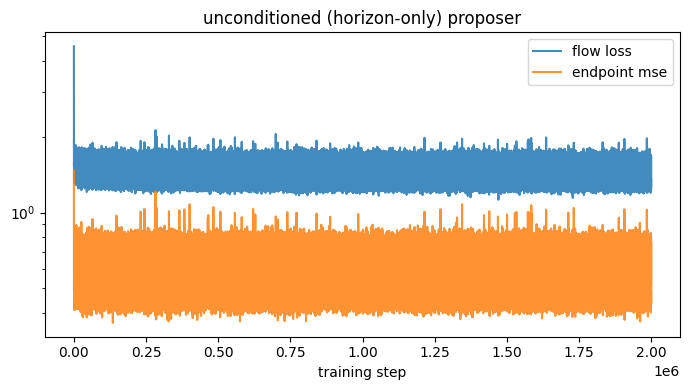

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_uncond['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(history_uncond['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.set_title('unconditioned (horizon-only) proposer')
ax.legend()
fig.tight_layout()

## Rollout comparison

Greedy subgoal chains (length 10, 128 candidates per step) for both proposers across all tasks. At each step the candidate closest in L2 oracle space to the task goal is selected as the next waypoint.

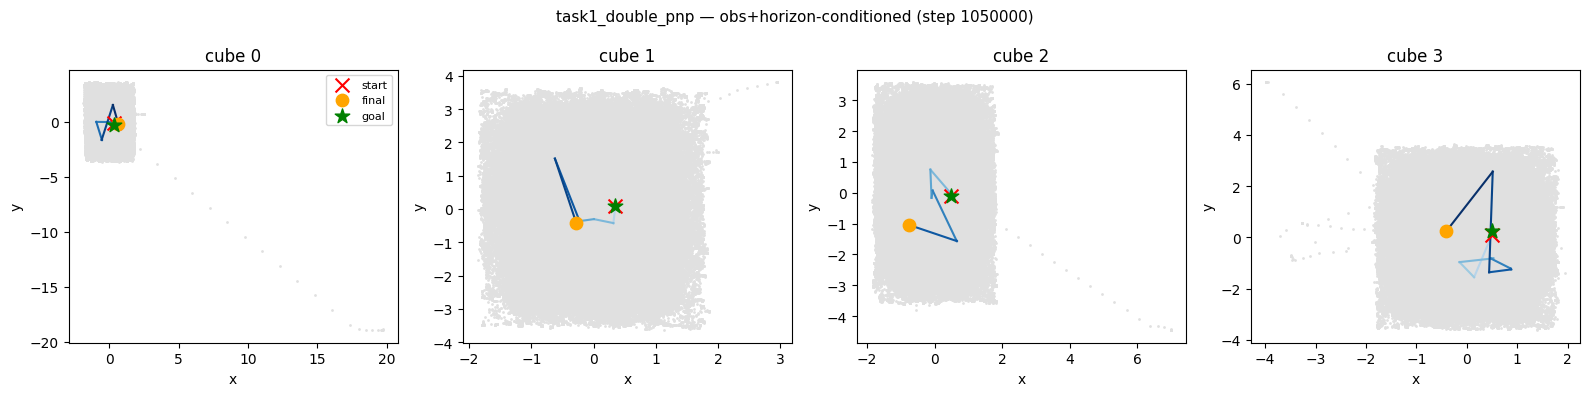

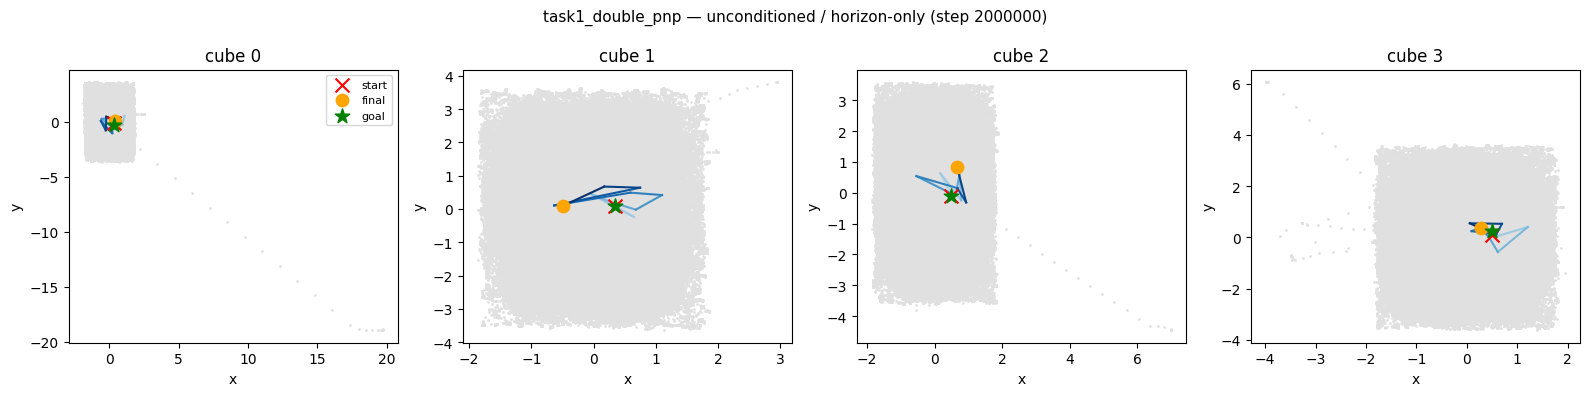

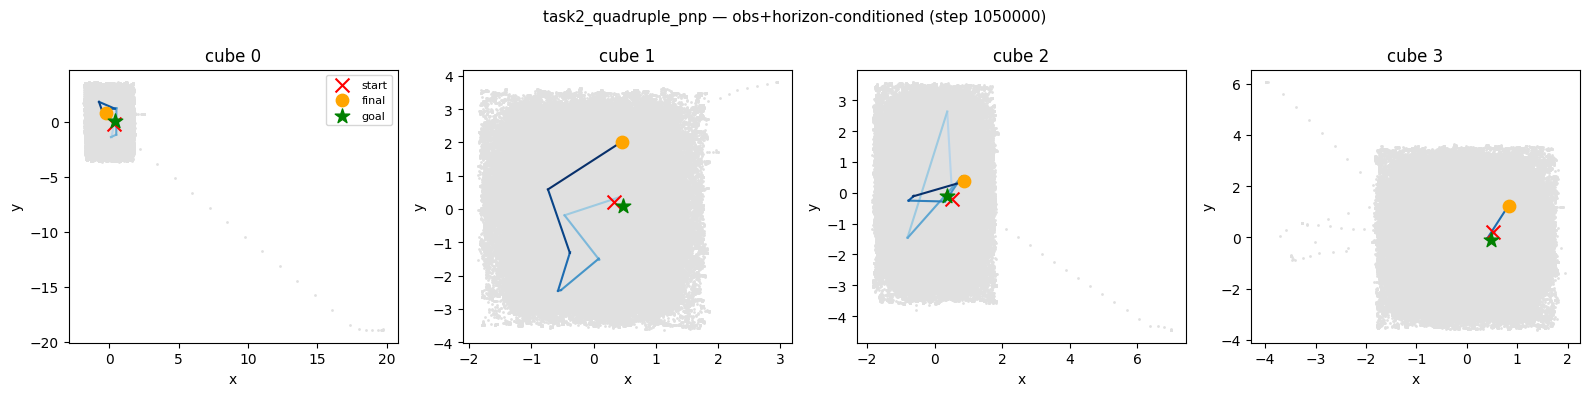

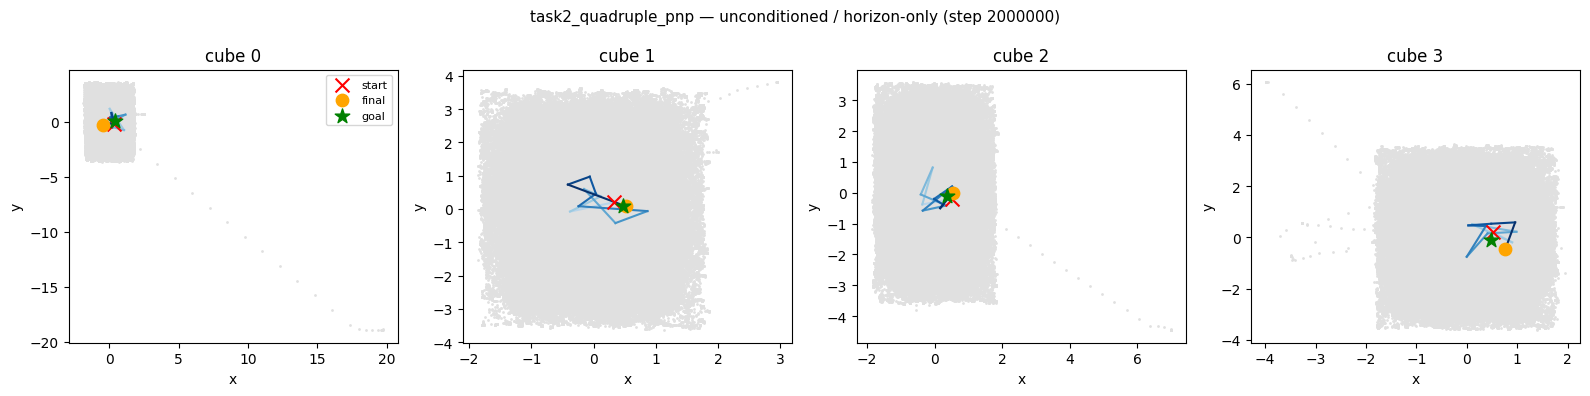

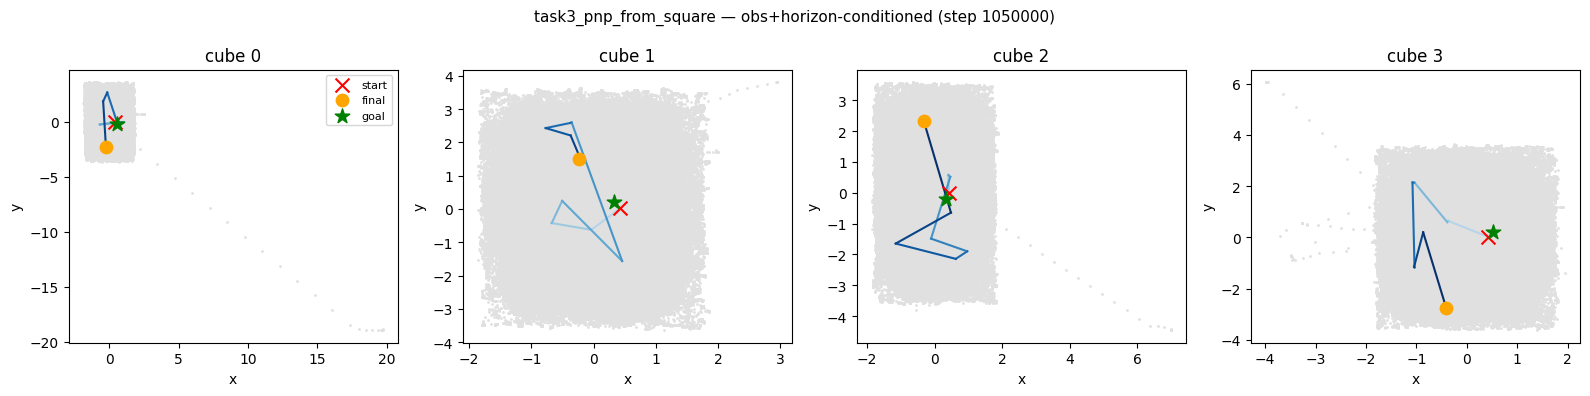

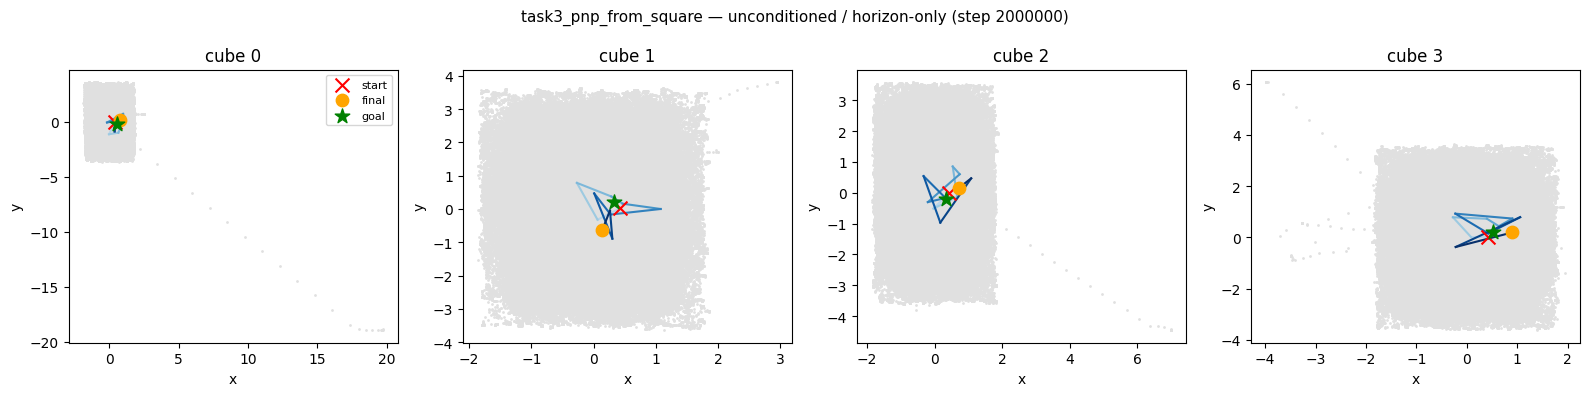

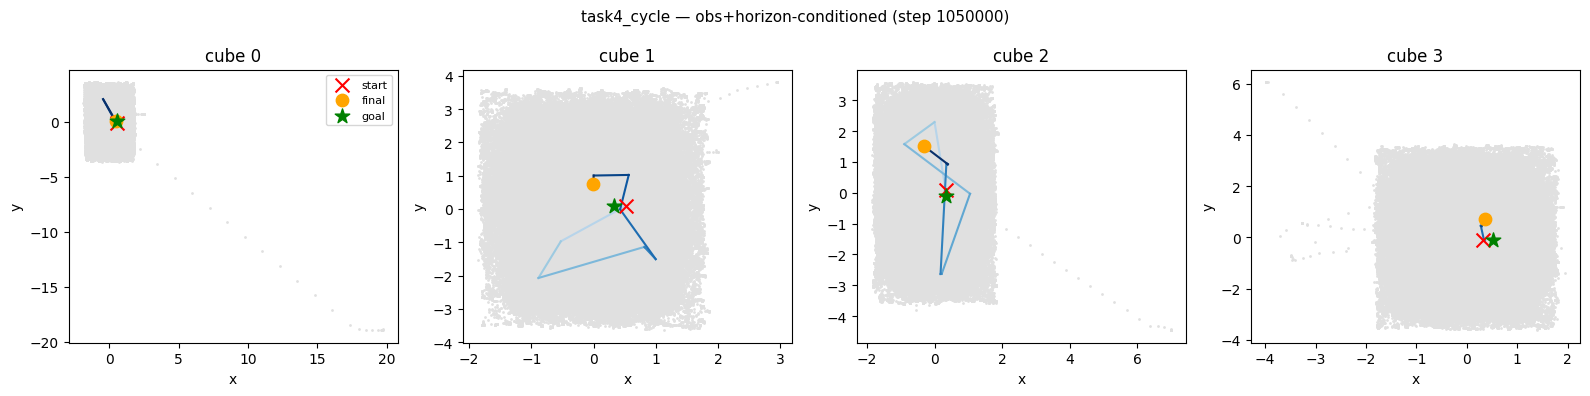

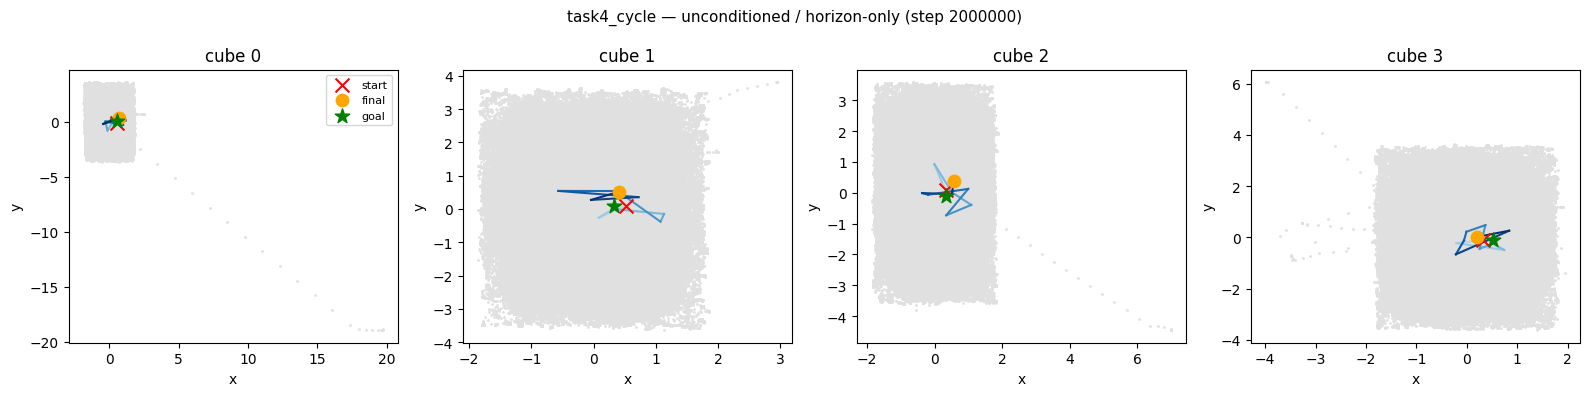

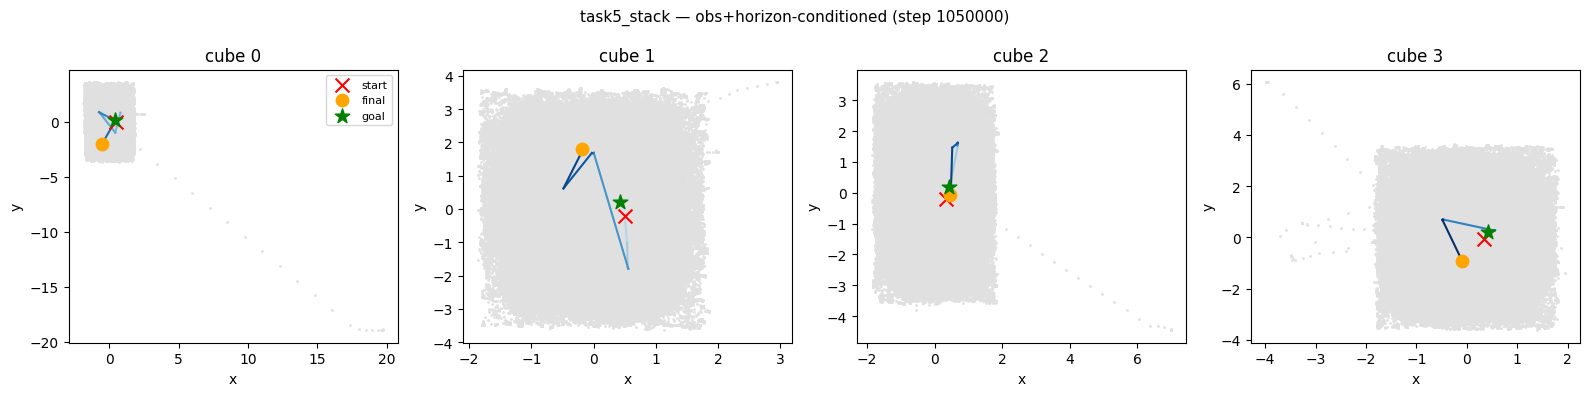

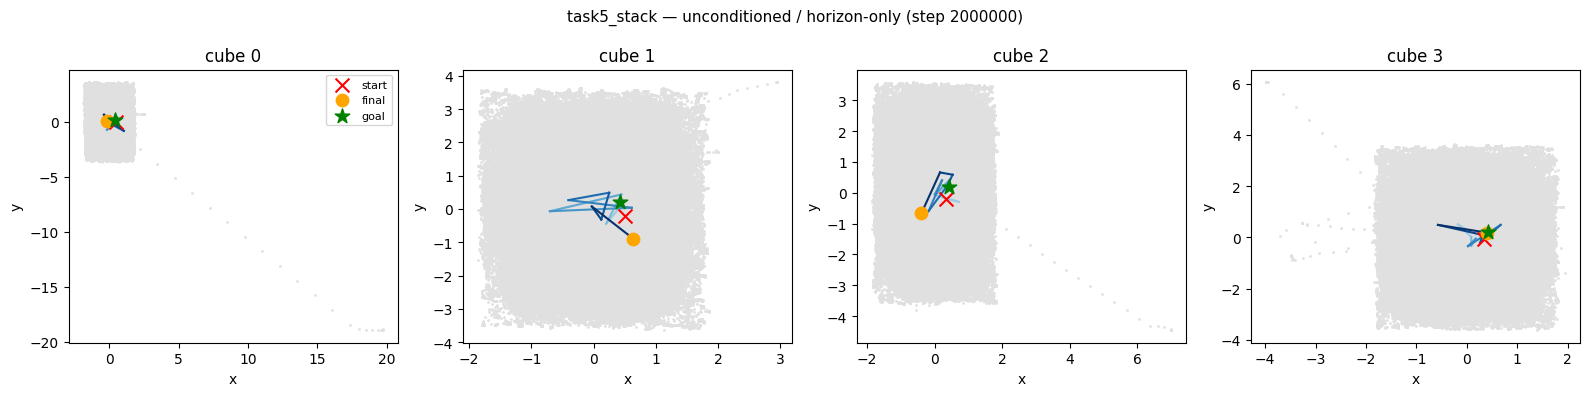

In [23]:
rollout_horizon = config['subgoal_steps']
rollout_num_samples = 128
rollout_num_steps = 10

rng = jax.random.PRNGKey(42)
for task_info in task_infos:
    start_oracle = task_info['init_xyzs'].flatten().astype(np.float32)
    goal_oracle = task_info['goal_xyzs'].flatten().astype(np.float32)
    task_name = task_info['task_name']

    rng, rng_cond, rng_uncond = jax.random.split(rng, 3)

    traj_cond = subgoal_rollout(
        agent, start_oracle, goal_oracle,
        horizon=rollout_horizon, num_samples=rollout_num_samples,
        num_steps=rollout_num_steps, rng=rng_cond,
    )
    traj_uncond = subgoal_rollout(
        uncond_agent, start_oracle, goal_oracle,
        horizon=rollout_horizon, num_samples=rollout_num_samples,
        num_steps=rollout_num_steps, rng=rng_uncond,
    )

    plot_subgoal_rollout(
        traj_cond, goal_oracle, all_cube_xyz, num_cubes,
        title=f'{task_name} — obs+horizon-conditioned (step {ckpt_step + EXTRA_STEPS})',
    )
    plt.show()

    plot_subgoal_rollout(
        traj_uncond, goal_oracle, all_cube_xyz, num_cubes,
        title=f'{task_name} — unconditioned / horizon-only (step {uncond_config["num_train_steps"]})',
    )
    plt.show()